In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sqlalchemy import create_engine

plt.style.use("ggplot")

In [2]:
engine = create_engine("sqlite:///../bluestock_mf.db")

In [3]:
nav = pd.read_sql("SELECT * FROM fact_nav", engine)

performance = pd.read_sql(
    "SELECT * FROM fact_performance",
    engine
)

transactions = pd.read_sql(
    "SELECT * FROM fact_transactions",
    engine
)

holdings = pd.read_sql(
    "SELECT * FROM fact_holdings",
    engine
)

In [4]:
nav.head()

performance.head()

transactions.head()

holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [5]:
print("NAV Shape:", nav.shape)
print("Performance Shape:", performance.shape)
print("Transactions Shape:", transactions.shape)
print("Holdings Shape:", holdings.shape)

NAV Shape: (46000, 3)
Performance Shape: (40, 19)
Transactions Shape: (32778, 13)
Holdings Shape: (322, 8)


In [6]:
# Convert date column to datetime
nav["date"] = pd.to_datetime(nav["date"])

# Sort by fund and date
nav = nav.sort_values(["amfi_code", "date"])

nav.head()


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [7]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [8]:
risk_metrics = []

for fund in nav["amfi_code"].unique():

    returns = (
        nav.loc[nav["amfi_code"] == fund, "daily_return"]
           .dropna()
    )

    var95 = np.percentile(returns, 5)

    cvar95 = returns[returns <= var95].mean()

    risk_metrics.append({
        "amfi_code": fund,
        "VaR_95": var95,
        "CVaR_95": cvar95
    })

risk_df = pd.DataFrame(risk_metrics)

risk_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [9]:
risk_df = risk_df.merge(
    performance[["amfi_code", "scheme_name"]],
    on="amfi_code"
)

risk_df.head()

,amfi_code,VaR_95,CVaR_95,scheme_name
0,100016,-0.014364,-0.018060,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.003793,-0.004994,HDFC Short Term Debt Fund - Regular - Growth
2,100033,-0.019034,-0.023456,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,-0.013282,-0.017439,ABSL Frontline Equity Fund - Regular - Growth
4,101207,-0.026021,-0.032459,ABSL Small Cap Fund - Regular - Growth


In [10]:
risk_df.sort_values(
    "VaR_95"
).head(10)

,amfi_code,VaR_95,CVaR_95,scheme_name
22,119599,-0.026859,-0.032384,SBI Small Cap Fund - Direct Plan - Growth
17,119095,-0.026188,-0.031667,Axis Small Cap Fund - Regular - Growth
4,101207,-0.026021,-0.032459,ABSL Small Cap Fund - Regular - Growth
11,118634,-0.025438,-0.032304,Nippon India Small Cap Fund - Regular - Growth
21,119598,-0.024507,-0.030595,SBI Small Cap Fund - Regular Plan - Growth
39,149324,-0.023483,-0.031036,DSP Small Cap Fund - Regular - Growth
7,102886,-0.019220,-0.023251,UTI Mid Cap Fund - Regular - Growth
2,100033,-0.019034,-0.023456,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
25,120505,-0.018892,-0.024342,ICICI Pru Midcap Fund - Regular - Growth
16,119094,-0.018480,-0.024260,Axis Midcap Fund - Regular - Growth


In [11]:
risk_df.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

print("Report saved successfully!")

Report saved successfully!


In [12]:
rolling_data = nav.copy()

rolling_data["rolling_mean"] = (
    rolling_data.groupby("amfi_code")["daily_return"]
    .transform(lambda x: x.rolling(90).mean())
)

rolling_data["rolling_std"] = (
    rolling_data.groupby("amfi_code")["daily_return"]
    .transform(lambda x: x.rolling(90).std())
)

rolling_data["rolling_sharpe"] = (
    rolling_data["rolling_mean"] /
    rolling_data["rolling_std"]
) * np.sqrt(252)

rolling_data.head()

,amfi_code,date,nav,daily_return,rolling_mean,rolling_std,rolling_sharpe
0,100016,2022-01-03,520.4608,NaN,NaN,NaN,NaN
1,100016,2022-01-04,515.0971,-0.010306,NaN,NaN,NaN
2,100016,2022-01-05,521.7239,0.012865,NaN,NaN,NaN
3,100016,2022-01-06,515.7880,-0.011377,NaN,NaN,NaN
4,100016,2022-01-07,515.1639,-0.001210,NaN,NaN,NaN


In [13]:
top5 = performance["amfi_code"].head(5).tolist()

top5

[119551, 119552, 119598, 119599, 119120]

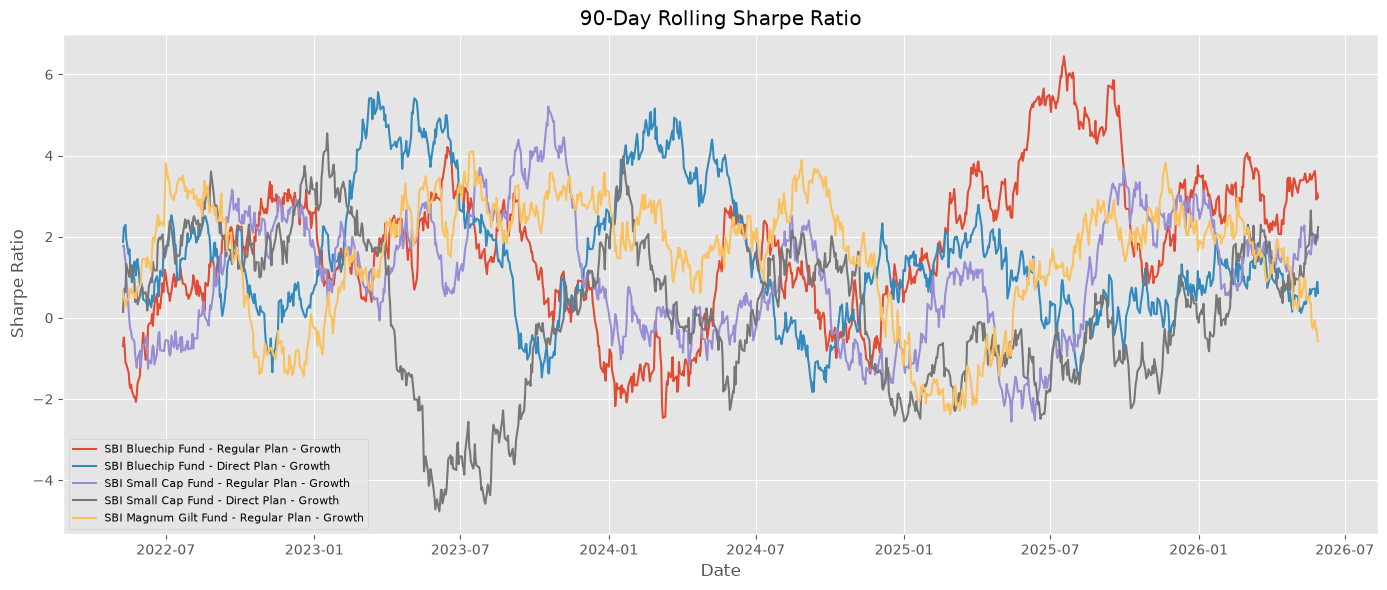

In [14]:
plt.figure(figsize=(14,6))

for fund in top5:

    df = rolling_data[
        rolling_data["amfi_code"] == fund
    ]

    name = performance.loc[
        performance["amfi_code"] == fund,
        "scheme_name"
    ].values[0]

    plt.plot(
        df["date"],
        df["rolling_sharpe"],
        label=name
    )

plt.title("90-Day Rolling Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

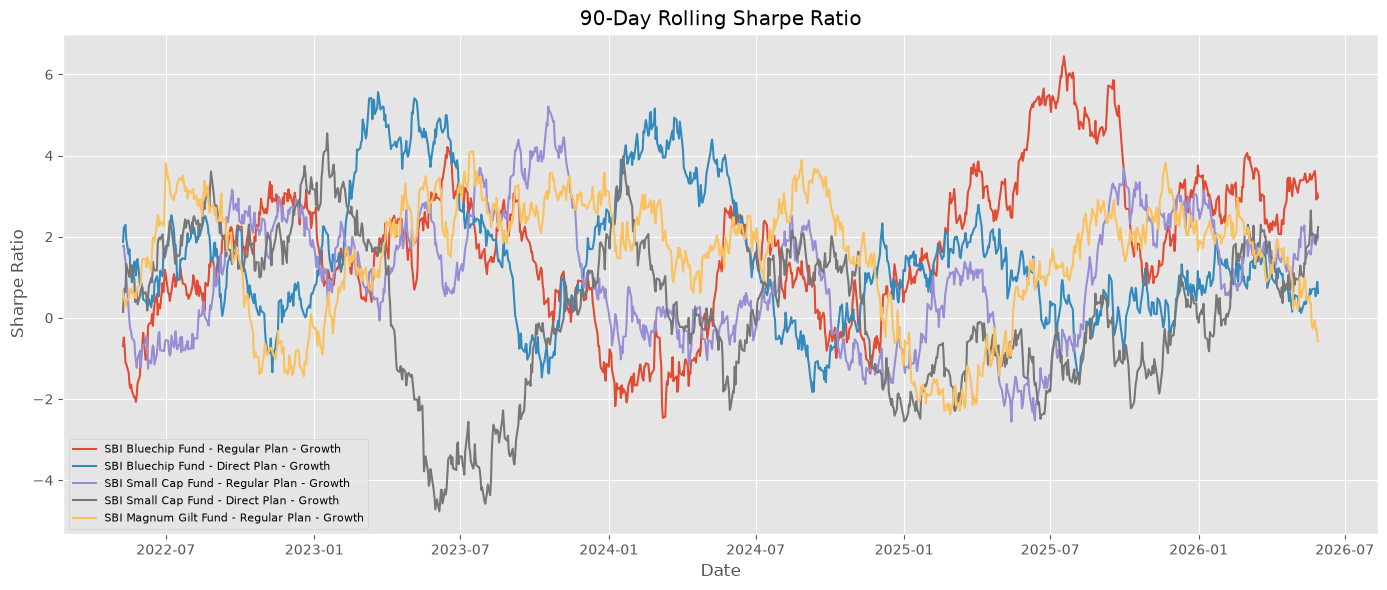

In [15]:
plt.figure(figsize=(14,6))

for fund in top5:

    df = rolling_data[
        rolling_data["amfi_code"] == fund
    ]

    name = performance.loc[
        performance["amfi_code"] == fund,
        "scheme_name"
    ].values[0]

    plt.plot(
        df["date"],
        df["rolling_sharpe"],
        label=name
    )

plt.title("90-Day Rolling Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend(fontsize=8)

plt.tight_layout()

plt.savefig(
    "../reports/rolling_sharpe_chart.png",
    dpi=300
)

plt.show()

In [16]:
average_sharpe = (
    rolling_data.groupby("amfi_code")["rolling_sharpe"]
    .mean()
    .reset_index()
)

average_sharpe = average_sharpe.merge(
    performance[["amfi_code", "scheme_name"]],
    on="amfi_code"
)

average_sharpe.sort_values(
    "rolling_sharpe",
    ascending=False
).head(10)

,amfi_code,rolling_sharpe,scheme_name
27,120507,13.558546,ICICI Pru Liquid Fund - Regular - Growth
31,120844,12.478178,Kotak Liquid Fund - Regular - Growth
5,101208,11.995642,ABSL Liquid Fund - Regular - Growth
30,120843,1.997692,Kotak Flexicap Fund - Regular - Growth
34,148567,1.890422,Mirae Asset Large Cap Fund - Regular - Growth
19,119551,1.727788,SBI Bluechip Fund - Regular Plan - Growth
2,100033,1.586154,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
24,120504,1.561429,ICICI Pru Bluechip Fund - Direct - Growth
38,149323,1.544997,DSP Midcap Fund - Regular - Growth
18,119120,1.529147,SBI Magnum Gilt Fund - Regular Plan - Growth


# Advanced Insights

## Insight 1
The 5-Year returns show that large-cap and flexi-cap funds generally outperform debt-oriented schemes.

## Insight 2
Historical VaR identifies a few schemes with significantly higher downside risk, making them suitable only for aggressive investors.

## Insight 3
Rolling Sharpe Ratio demonstrates that several funds consistently maintain superior risk-adjusted returns over time.

## Insight 4
Investor transaction analysis indicates SIP remains the dominant investment mode compared to lump-sum investments.

## Insight 5
Sector concentration analysis shows that Financial Services and Information Technology contribute the largest portfolio weights across equity funds.